In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, sklearn, sklearn.metrics

In [2]:
df_pairs_ = pd.read_csv('mgen_pairwise.tsv', sep='\t')
# Pools were generated randomly so interactions have lots of redundancy; pick first as the representative
df_pairs_ = df_pairs_.groupby(['group', 'af3_id1', 'af3_id2']).head(1).reset_index()

In [3]:
df_pairs_['string_experimental_800'] = df_pairs_['string_experimental'] > 800
df_pairs_['string_experimental_800'].value_counts()

string_experimental_800
False    21877
True       543
Name: count, dtype: int64

In [4]:
def auc_(group, labels_col_='string_experimental_800', scores_col_='pair_iptm_mean'):
    df_pairs_subset_ = df_pairs_.query('group == @group')
    labels_ = df_pairs_subset_[labels_col_].tolist()
    scores_ = df_pairs_subset_[scores_col_].tolist()
    auc_ = sklearn.metrics.roc_auc_score(y_true=labels_, y_score=scores_)
    return group, sum(df_pairs_subset_[labels_col_]), sum(~df_pairs_subset_[labels_col_]), auc_, scores_col_

aucs_ = pd.DataFrame.from_records([
    auc_("pairs", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean'),
    auc_("pools_2k", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean'),
    auc_("pools_3k", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean'),
    auc_("pools_4k", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean'),
    auc_("pools_5k", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean'),
    auc_("pairs", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean_corrected'),
    auc_("pools_2k", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean_corrected'),
    auc_("pools_3k", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean_corrected'),
    auc_("pools_4k", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean_corrected'),
    auc_("pools_5k", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean_corrected'),
], columns=['group', 'n_pos', 'n_neg', 'auc', 'metric'])
aucs_

,group,n_pos,n_neg,auc,metric
0,pairs,135,4425,0.359057,pair_iptm_mean
1,pools_2k,40,4425,0.414206,pair_iptm_mean
2,pools_3k,98,4367,0.361665,pair_iptm_mean
3,pools_4k,107,4358,0.375783,pair_iptm_mean
4,pools_5k,163,4302,0.296942,pair_iptm_mean
5,pairs,135,4425,0.449825,pair_iptm_mean_corrected
6,pools_2k,40,4425,0.621189,pair_iptm_mean_corrected
7,pools_3k,98,4367,0.672907,pair_iptm_mean_corrected
8,pools_4k,107,4358,0.757553,pair_iptm_mean_corrected
9,pools_5k,163,4302,0.800973,pair_iptm_mean_corrected


In [5]:
df_runtime_ = pd.read_csv('mgen_pools.tsv', sep='\t').merge(pd.read_csv('mgen_runtimes.tsv', sep='\t')[['name', 'runtime_sec']], on='name')
df_runtime_['n_interactions'] = df_runtime_['pool_nchains'] * (df_runtime_['pool_nchains'] - 1) // 2
df_runtime_['interaction_runtime_sec'] = df_runtime_['runtime_sec'] / df_runtime_['n_interactions']
df_runtime_.groupby('group')['interaction_runtime_sec'].median()

group
pairs       55.815000
pools_2k    54.672000
pools_3k    34.425833
pools_4k    25.496818
pools_5k    22.257059
Name: interaction_runtime_sec, dtype: float64

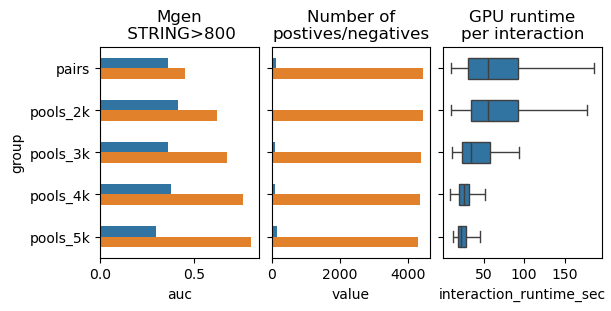

In [6]:
width_ = .5
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(6, 3), constrained_layout=True, sharey=True)
plt.subplot(1, 3, 1)
plt.title(f'Mgen\n STRING>800')
sns.barplot(aucs_, x='auc', y='group', hue='metric', width=width_)
plt.legend([],[], frameon=False)

plt.subplot(1, 3, 2)
plt.title(f'Number of\npostives/negatives')
data_ = pd.melt(aucs_[['group', 'n_pos', 'n_neg']], id_vars='group', value_vars=['n_pos', 'n_neg'])
sns.barplot(data_, x='value', y='group', hue='variable', width=width_)
plt.legend([],[], frameon=False)

plt.subplot(1, 3, 3)
plt.title(f'GPU runtime\nper interaction')
sns.boxplot(df_runtime_.sort_values('group'), x='interaction_runtime_sec', y='group', width=width_, showfliers=False)
plt.savefig('mgen_pairwise.svg', bbox_inches='tight', transparent=True)